# HyFIN-Net — M4 Ablation: Implicit Edge Quality

Implements the M4 grid from `m2_m3_m4_m6_implementation_plan.md`:
E0 off (the reference), E1 shared detector (current design),
E2 per-modality detectors with score-once caching, E3 + Gumbel top-k
selection, E4 CAD counterfactual scoring (closed-form leave-one-out).

**Every variant is judged against E0, not E1** — implicit edges must first
earn their place at all. Prior B4 result: removing implicit edges *helped*
(+0.0090 wF1), so E0 is a strong reference.

**Deviation from the plan, deliberate:** in the baseline the detector scores
are discarded after thresholding, so `ImplicitEdgeDetector.W` never receives
a gradient — it is a frozen random projection. Here detector scores are used
as the edge weights of implicit edges (explicit edges keep `angular_weight`),
which gives every detector a real training signal.


In [2]:
import subprocess, sys, importlib
def _try(mod):
    try:
        importlib.import_module(mod); return True
    except Exception:
        return False
if not _try('torch_scatter') or not _try('torch_sparse'):
    import torch as _t
    tv = _t.__version__.split('+')[0]
    cu = _t.version.cuda.replace('.', '') if _t.version.cuda else 'cpu'
    url = f'https://data.pyg.org/whl/torch-{tv}+cu{cu}.html'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-index',
                    'torch_scatter', 'torch_sparse', '-f', url], check=False)
    if not _try('torch_geometric'):
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=False)
import torch, torch_geometric
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| pyg', torch_geometric.__version__)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
import os
IS_KAGGLE = os.path.exists('/kaggle/working')
print('Platform: Kaggle' if IS_KAGGLE else 'Platform: local')

torch 2.11.0+cu128 | cuda 12.8 | pyg 2.7.0
GPU: NVIDIA GeForce RTX 3060
Platform: local


In [3]:
import os, pickle, math, random, time, copy, json
from pathlib import Path
from itertools import permutations
from dataclasses import dataclass, field
from typing import Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GraphConv, TransformerConv
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax as pyg_softmax, degree
from torch_scatter import scatter_add
from sklearn.metrics import f1_score, accuracy_score, classification_report

SEED = 2024
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

# ── Ablation-study settings ───────────────────────────────────────────────────
ABLATION_EPOCHS = 30          # use 60 for full-fidelity; 30 for fast sweep
ABLATION_SEED   = 42

device = cuda


In [4]:
_LOCAL_DATA_ROOT = os.environ.get(
    'GRAPHSMILE_DATA',
    str(Path('/mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed')))
_LOCAL_SAVE_DIR = os.environ.get('HYFIN_SAVE_DIR', './outputs')

class Cfg:
    dataset      = 'iemocap'
    data_root    = ('/kaggle/input/datasets/gilbertstrange/graphsmile-preprocessed/GraphSmile_PreProcessed'
                    if IS_KAGGLE else _LOCAL_DATA_ROOT)
    save_dir     = '/kaggle/working' if IS_KAGGLE else _LOCAL_SAVE_DIR
    @property
    def meld_path(self):    return f'{self.data_root}/meld_multi_features.pkl'
    @property
    def iemocap_path(self): return f'{self.data_root}/iemocap_multi_features.pkl'
    batch_size_d = {'iemocap': 16, 'meld': 32}
    epochs       = 60      # full training epochs (not used for ablation)
    lr           = 4e-4
    weight_decay = 1e-4
    grad_clip    = 1.0
    warmup_epochs = 1
    label_smoothing = 0.1
    hidden       = 256
    n_speakers   = {'iemocap': 2, 'meld': 9}
    n_classes    = {'iemocap': 6, 'meld': 7}
    igm_branches = {
        'iemocap': [(5, 3), (3, 2)],
        'meld':    [(7, 4), (5, 3)],
    }
    igm_layers   = 2
    igm_heads    = 4
    hm_layers    = {'iemocap': 2, 'meld': 4}
    mf_layers    = {'iemocap': 4, 'meld': 3}
    ca_heads     = 4
    dropout      = {'iemocap': 0.5, 'meld': 0.5}
    beta_cb      = 0.999
    cbfc_mu      = 0.1
    cbfc_gamma   = 2.0
    cbfc_temp    = 0.5
    dualcl_lam   = 0.0
    dualcl_tau   = 0.5
    dualcl_drop  = 0.1
    max_hm_nodes = 50_000
    max_hm_edges = 50_000
    val_frac     = 0.1
    log_every    = 999999   # suppress step-level logs during ablation sweep
    @property
    def batch_size(self): return self.batch_size_d[self.dataset]

cfg = Cfg()
os.makedirs(cfg.save_dir, exist_ok=True)
print(f'data_root: {cfg.data_root}')
print(f'save_dir : {cfg.save_dir}')

data_root: /mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed
save_dir : ./outputs


In [5]:
ABL_OUT  = Path(cfg.save_dir) / 'ablation_m4'
PLOT_DIR = ABL_OUT / 'plots'
CKPT_DIR = ABL_OUT / 'checkpoints'
RESULTS_FILE = ABL_OUT / 'ablation_m4_results.json'

for d in [ABL_OUT, PLOT_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def _load_results():
    if RESULTS_FILE.exists():
        with open(RESULTS_FILE) as f:
            return json.load(f)
    return {}

def _save_results(results):
    with open(RESULTS_FILE, 'w') as f:
        json.dump(results, f, indent=2)

print('Output dir:', ABL_OUT)


Output dir: outputs/ablation_m4


In [6]:
def _load_pickle(path):
    with open(path, 'rb') as f:
        try:
            return pickle.load(f, encoding='latin1')
        except TypeError:
            f.seek(0); return pickle.load(f)

def parse_graphsmile_pickle(path, dataset):
    obj = _load_pickle(path)
    assert isinstance(obj, (tuple, list)), f'unexpected pickle type {type(obj)}'
    n = len(obj)
    if n == 9:
        (videoIDs, videoSpeakers, videoLabels,
         videoText, videoAudio, videoVisual, videoSentence,
         trainVid, testVid) = obj
        text_dict = videoText
    elif n in (12,):
        (videoIDs, videoSpeakers, videoLabels,
         vT0, vT1, vT2, vT3,
         videoAudio, videoVisual, videoSentence,
         trainVid, testVid) = obj
        text_dict = {vid: (np.asarray(vT0[vid], dtype=np.float32)
                          + np.asarray(vT1[vid], dtype=np.float32)
                          + np.asarray(vT2[vid], dtype=np.float32)
                          + np.asarray(vT3[vid], dtype=np.float32)) / 4.0
                     for vid in vT0.keys()}
    elif n in (13, 14):
        (videoIDs, videoSpeakers, videoLabels, videoSentiments,
         vT0, vT1, vT2, vT3,
         videoAudio, videoVisual, videoSentence,
         trainVid, testVid, *rest) = obj
        text_dict = {vid: (np.asarray(vT0[vid], dtype=np.float32)
                          + np.asarray(vT1[vid], dtype=np.float32)
                          + np.asarray(vT2[vid], dtype=np.float32)
                          + np.asarray(vT3[vid], dtype=np.float32)) / 4.0
                     for vid in vT0.keys()}
    else:
        raise ValueError(f'unsupported pickle layout: {n} fields')

    sample_vid = next(iter(text_dict))
    Dt = int(np.asarray(text_dict[sample_vid]).shape[-1])
    Da = int(np.asarray(videoAudio[sample_vid]).shape[-1])
    Dv = int(np.asarray(videoVisual[sample_vid]).shape[-1])
    print(f'  layout={n} fields  dims t/a/v = {Dt}/{Da}/{Dv}  train={len(trainVid)}, test={len(testVid)}')
    return dict(text=text_dict, audio=videoAudio, visual=videoVisual,
                labels=videoLabels, speakers=videoSpeakers, sentences=videoSentence,
                trainVid=list(trainVid), testVid=list(testVid))

def _speaker_to_idx(spk, dataset):
    if dataset == 'iemocap':
        out = []
        for s in spk:
            if isinstance(s, (str, bytes)):
                ss = s.decode() if isinstance(s, bytes) else s
                out.append({'M': 0, 'F': 1}.get(ss, 0))
            else:
                out.append(int(s))
        return out
    arr = np.asarray(spk)
    if arr.ndim == 2:
        return arr.argmax(-1).tolist()
    return arr.astype(int).tolist()

class MERCDataset(Dataset):
    def __init__(self, raw, vids, dataset):
        self.raw = raw; self.vids = vids; self.dataset = dataset
    def __len__(self): return len(self.vids)
    def __getitem__(self, idx):
        vid = self.vids[idx]
        t = np.asarray(self.raw['text'][vid],   dtype=np.float32)
        a = np.asarray(self.raw['audio'][vid],  dtype=np.float32)
        v = np.asarray(self.raw['visual'][vid], dtype=np.float32)
        y = np.asarray(self.raw['labels'][vid], dtype=np.int64)
        spk = _speaker_to_idx(self.raw['speakers'][vid], self.dataset)
        return {
            'text': torch.from_numpy(t), 'audio': torch.from_numpy(a),
            'visual': torch.from_numpy(v), 'label': torch.from_numpy(y),
            'speaker': torch.tensor(spk, dtype=torch.long),
            'length': int(t.shape[0]),
        }

def pad_collate(batch):
    B = len(batch)
    L = max(s['length'] for s in batch)
    Dt = batch[0]['text'].shape[-1]
    Da = batch[0]['audio'].shape[-1]
    Dv = batch[0]['visual'].shape[-1]
    text   = torch.zeros(B, L, Dt)
    audio  = torch.zeros(B, L, Da)
    visual = torch.zeros(B, L, Dv)
    spk    = torch.zeros(B, L, dtype=torch.long)
    lens   = torch.zeros(B, dtype=torch.long)
    labels = []
    for i, s in enumerate(batch):
        n = s['length']
        text[i, :n]   = s['text']
        audio[i, :n]  = s['audio']
        visual[i, :n] = s['visual']
        spk[i, :n]    = s['speaker']
        lens[i]       = n
        labels.append(s['label'])
    return {'text': text, 'audio': audio, 'visual': visual,
            'speaker': spk, 'lengths': lens, 'labels': torch.cat(labels)}

# Load data
path = cfg.meld_path if cfg.dataset == 'meld' else cfg.iemocap_path
print(f'loading {path}')
raw = parse_graphsmile_pickle(path, dataset=cfg.dataset)
print('train vids:', len(raw['trainVid']), 'test vids:', len(raw['testVid']))

probe_dims = []
for vid in list(raw['trainVid'])[:5]:
    t = np.asarray(raw['text'][vid]); a = np.asarray(raw['audio'][vid]); v = np.asarray(raw['visual'][vid])
    probe_dims.append((t.shape[-1], a.shape[-1], v.shape[-1]))
assert len(set(probe_dims)) == 1
D_T, D_A, D_V = probe_dims[0]
print(f'feature dims t/a/v = {D_T}/{D_A}/{D_V}')

# Split
train_all = list(raw['trainVid'])
rng = random.Random(SEED); rng.shuffle(train_all)
n_val = max(1, int(len(train_all) * cfg.val_frac))
val_vids   = train_all[:n_val]
train_vids = train_all[n_val:]
test_vids  = list(raw['testVid'])

num_workers = 2 if IS_KAGGLE else min(4, os.cpu_count() or 1)
train_set  = MERCDataset(raw, train_vids, cfg.dataset)
val_set    = MERCDataset(raw, val_vids,   cfg.dataset)
test_set   = MERCDataset(raw, test_vids,  cfg.dataset)
train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,
                          collate_fn=pad_collate, num_workers=num_workers, pin_memory=IS_KAGGLE)
val_loader   = DataLoader(val_set,   batch_size=cfg.batch_size, shuffle=False,
                          collate_fn=pad_collate, num_workers=num_workers, pin_memory=IS_KAGGLE)
test_loader  = DataLoader(test_set,  batch_size=cfg.batch_size, shuffle=False,
                          collate_fn=pad_collate, num_workers=num_workers, pin_memory=IS_KAGGLE)
print(f'split: train={len(train_set)}  val={len(val_set)}  test={len(test_set)}')

class_counts = np.zeros(cfg.n_classes[cfg.dataset], dtype=np.int64)
for vid in train_vids:
    for y in raw['labels'][vid]:
        class_counts[int(y)] += 1
print('train class counts:', class_counts.tolist())

loading /mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed/iemocap_multi_features.pkl
  layout=12 fields  dims t/a/v = 1024/1582/342  train=120, test=31
train vids: 120 test vids: 31
feature dims t/a/v = 1024/1582/342
split: train=108  val=12  test=31
train class counts: [474, 763, 1200, 814, 711, 1267]


## Original Model Classes (verbatim from arch21.ipynb)

In [7]:
# ── Block A: Unimodal Encoder ─────────────────────────────────────────────────

class InputLN(nn.Module):
    """Masked per-dialogue LayerNorm over each dialogue's TRUE (unpadded) (n, D) block."""
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps
    def forward(self, x, lengths):
        B, L, D = x.shape
        if L == 0:
            return x
        valid = (torch.arange(L, device=x.device)[None, :] < lengths[:, None]).unsqueeze(-1)
        vf = valid.to(x.dtype)
        cnt = (vf.sum(dim=(1, 2), keepdim=True) * D).clamp(min=1.0)
        mean = (x * vf).sum(dim=(1, 2), keepdim=True) / cnt
        var = (((x - mean) ** 2) * vf).sum(dim=(1, 2), keepdim=True) / cnt
        out = (x - mean) / torch.sqrt(var + self.eps)
        return out * vf

class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class UnimodalEncoder(nn.Module):
    def __init__(self, d_t, d_a, d_v, d_h, n_speakers, dropout=0.5):
        super().__init__()
        self.in_ln_t = InputLN()
        self.in_ln_a = InputLN()
        self.in_ln_v = InputLN()
        self.t_proj = nn.Linear(d_t, d_h)
        self.pe     = PositionalEncoding(d_h)
        self.t_enc  = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_h, nhead=4, dim_feedforward=d_h,
                                       dropout=dropout, activation='gelu', batch_first=True),
            num_layers=1)
        self.a_proj = nn.Sequential(nn.Linear(d_a, d_h), nn.ReLU(), nn.Dropout(dropout))
        self.v_proj = nn.Sequential(nn.Linear(d_v, d_h), nn.ReLU(), nn.Dropout(dropout))
        self.spk    = nn.Embedding(n_speakers, d_h)
    def forward(self, text, audio, visual, spk, lengths):
        B, L, _ = text.shape
        mask = torch.arange(L, device=text.device)[None] >= lengths[:, None]
        text   = self.in_ln_t(text,   lengths)
        audio  = self.in_ln_a(audio,  lengths)
        visual = self.in_ln_v(visual, lengths)
        ht = self.t_enc(self.pe(self.t_proj(text)), src_key_padding_mask=mask)
        ha = self.a_proj(audio)
        hv = self.v_proj(visual)
        s = self.spk(spk)
        return ht + s, ha + s, hv + s, mask

# ── Graph helpers ─────────────────────────────────────────────────────────────

def flatten_batch(ht, ha, hv, lengths):
    feats, offsets = [], []; cur = 0
    for b, n in enumerate(lengths.tolist()):
        feats.append(torch.cat([ht[b, :n], ha[b, :n], hv[b, :n]], dim=0))
        offsets.append(cur); cur += 3 * n
    return torch.cat(feats, dim=0), offsets

def unflatten_batch(flat, lengths, offsets):
    B = len(lengths); L = int(lengths.max().item()); H = flat.shape[-1]
    ht = flat.new_zeros(B, L, H); ha = flat.new_zeros(B, L, H); hv = flat.new_zeros(B, L, H)
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]
        ht[b, :n] = flat[o:o+n]; ha[b, :n] = flat[o+n:o+2*n]; hv[b, :n] = flat[o+2*n:o+3*n]
    return ht, ha, hv

def angular_weight(x, edge_index):
    src, dst = edge_index
    xs = F.normalize(x[src], dim=-1); xd = F.normalize(x[dst], dim=-1)
    cos = (xs * xd).sum(-1).clamp(-1 + 1e-6, 1 - 1e-6)
    return 1.0 - torch.arccos(cos) / math.pi

# ── Block B-IGM: Inception Graph Module ──────────────────────────────────────

class ImplicitEdgeDetector(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.W = nn.Linear(2 * d, 1, bias=False)
        self.act = nn.LeakyReLU(0.2)
    def extra_edges(self, feats_per_modality, n):
        if n < 2: return None, None
        f = feats_per_modality
        fi = f.unsqueeze(1).expand(n, n, -1)
        fj = f.unsqueeze(0).expand(n, n, -1)
        s = self.act(self.W(torch.cat([fi, fj], dim=-1)).squeeze(-1))
        causal = torch.tril(torch.ones(n, n, device=f.device, dtype=torch.bool))
        s = s.masked_fill(~causal, -1e9)
        a = F.softmax(s, dim=-1)
        keep = (a > (1.0 / n)) & causal
        idx = keep.nonzero(as_tuple=False)
        if idx.numel() == 0: return None, None
        return idx[:, 0], idx[:, 1]

def build_igm_graph(lengths, offsets, ht, ha, hv, p_window, f_window, implicit=None, device='cpu'):
    src, dst = [], []; feats_for_implicit = (ht, ha, hv)
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]
        t0, a0, v0 = o, o + n, o + 2 * n
        idx_t = torch.arange(n, device=device) + t0
        idx_a = torch.arange(n, device=device) + a0
        idx_v = torch.arange(n, device=device) + v0
        for x, y in [(idx_t, idx_a), (idx_t, idx_v), (idx_a, idx_v)]:
            src.append(x); dst.append(y); src.append(y); dst.append(x)
        for idx in (idx_t, idx_a, idx_v):
            i_grid = torch.arange(n, device=device)
            for shift in range(1, p_window + 1):
                m = i_grid >= shift
                if m.any():
                    src.append(idx[m]); dst.append(idx[m] - shift)
                    src.append(idx[m] - shift); dst.append(idx[m])
            for shift in range(1, f_window + 1):
                m = (i_grid + shift) < n
                if m.any():
                    src.append(idx[m]); dst.append(idx[m] + shift)
                    src.append(idx[m] + shift); dst.append(idx[m])
        if implicit is not None:
            for mod_idx, base in enumerate([t0, a0, v0]):
                mod_feats = feats_for_implicit[mod_idx][b, :n]
                u, w = implicit.extra_edges(mod_feats, n)
                if u is not None:
                    u = u + base; w = w + base
                    src.append(u); dst.append(w); src.append(w); dst.append(u)
    if len(src) == 0:
        return torch.zeros(2, 0, dtype=torch.long, device=device)
    src = torch.cat(src, dim=0); dst = torch.cat(dst, dim=0)
    return torch.stack([src, dst], dim=0)

class IGMBranch(nn.Module):
    def __init__(self, d, n_layers, heads=4, dropout=0.1):
        super().__init__()
        assert d % heads == 0
        d_head = d // heads
        self.convs = nn.ModuleList([
            TransformerConv(in_channels=d, out_channels=d_head, heads=heads,
                            concat=True, beta=True, dropout=dropout, edge_dim=1)
            for _ in range(n_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_layers)])
    def forward(self, x, edge_index, edge_weight=None):
        edge_attr = None if edge_weight is None else edge_weight.unsqueeze(-1)
        h = x
        for conv, ln in zip(self.convs, self.norms):
            h = ln(F.relu(conv(h, edge_index, edge_attr)) + h)
        return h

class InceptionGraphModule(nn.Module):
    def __init__(self, d, windows, n_layers, heads=4, dropout=0.1):
        super().__init__()
        self.windows = windows
        self.branches = nn.ModuleList([IGMBranch(d, n_layers, heads=heads, dropout=dropout)
                                       for _ in windows])
        self.implicit = ImplicitEdgeDetector(d)
    def forward(self, flat, lengths, offsets, ht, ha, hv):
        outs = []
        for (p, f), branch in zip(self.windows, self.branches):
            edge_index = build_igm_graph(lengths, offsets, ht, ha, hv,
                                         p, f, implicit=self.implicit, device=flat.device)
            ew = angular_weight(flat, edge_index)
            outs.append(branch(flat, edge_index, ew))
        return torch.stack(outs, dim=0).mean(dim=0)

# ── Block B-HM: Hypergraph Module ────────────────────────────────────────────

class HypergraphConvM3(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.lin = nn.Linear(d_in, d_out, bias=False)
        self.bias = nn.Parameter(torch.zeros(d_out))
    def forward(self, x, hyperedge_index, hyperedge_weight=None, ew_weight=None):
        N = x.size(0)
        if hyperedge_index.numel() == 0:
            return F.leaky_relu(self.lin(x) + self.bias)
        node_idx, edge_idx = hyperedge_index[0], hyperedge_index[1]
        E = int(edge_idx.max().item()) + 1
        if hyperedge_weight is None:
            hyperedge_weight = x.new_ones(E)
        D = scatter_add(hyperedge_weight[edge_idx], node_idx, dim=0, dim_size=N)
        D = 1.0 / D; D[D == float('inf')] = 0
        if ew_weight is None:
            B_ = scatter_add(x.new_ones(hyperedge_index.size(1)), edge_idx, dim=0, dim_size=E)
        else:
            B_ = scatter_add(ew_weight[node_idx], edge_idx, dim=0, dim_size=E)
        B_ = 1.0 / B_; B_[B_ == float('inf')] = 0
        h = self.lin(x)
        msg_n2e = h[node_idx] * B_[edge_idx].unsqueeze(-1)
        out_e   = scatter_add(msg_n2e, edge_idx, dim=0, dim_size=E)
        msg_e2n = out_e[edge_idx] * D[node_idx].unsqueeze(-1)
        out_n   = scatter_add(msg_e2n, node_idx, dim=0, dim_size=N)
        return F.leaky_relu(out_n + self.bias)

def build_hyperedge_index(lengths, offsets, device):
    nodes, edges = [], []; edge_count = 0
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]; t0, a0, v0 = o, o + n, o + 2 * n
        for base in (t0, a0, v0):
            for k in range(n):
                nodes.append(base + k); edges.append(edge_count)
            edge_count += 1
        for k in range(n):
            nodes.extend([t0 + k, a0 + k, v0 + k])
            edges.extend([edge_count] * 3); edge_count += 1
    if len(nodes) == 0:
        return torch.zeros(2, 0, dtype=torch.long, device=device)
    return torch.tensor([nodes, edges], dtype=torch.long, device=device)

class HyperGraphModule(nn.Module):
    def __init__(self, d, n_layers, max_nodes=50_000, max_edges=50_000):
        super().__init__()
        self.convs = nn.ModuleList([HypergraphConvM3(d, d) for _ in range(n_layers)])
        self.hyperedge_weight = nn.Parameter(torch.ones(max_edges))
        self.ew_weight        = nn.Parameter(torch.ones(max_nodes))
    def forward(self, flat, lengths, offsets):
        hi = build_hyperedge_index(lengths, offsets, flat.device)
        E = int(hi[1].max().item()) + 1; N = flat.size(0)
        w = self.hyperedge_weight[:E]; ew = self.ew_weight[:N]
        h = flat
        for conv in self.convs:
            h = conv(h, hi, w, ew)
        return h

# ── Block C: Multi-Frequency Module ──────────────────────────────────────────

class HighFreqConv(MessagePassing):
    def __init__(self, d):
        super().__init__(aggr='add')
        self.gate = nn.Linear(2 * d, 1)
    def forward(self, x, edge_index):
        return self.propagate(edge_index, size=(x.size(0), x.size(0)), x=x)
    def message(self, x_i, x_j, edge_index, size):
        row, col = edge_index
        deg_ = degree(row, size[0], dtype=x_j.dtype)
        d_inv = deg_.pow(-0.5)
        norm  = d_inv[row] * d_inv[col]
        a_g   = torch.tanh(self.gate(torch.cat([x_i, x_j], dim=1)))
        return norm.view(-1, 1) * x_j * a_g

def build_mf_edges(lengths, offsets, device):
    src, dst = [], []
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]; t0, a0, v0 = o, o + n, o + 2 * n
        for base in (t0, a0, v0):
            for pair in permutations(range(n), 2):
                src.append(base + pair[0]); dst.append(base + pair[1])
        for k in range(n):
            ids = [t0 + k, a0 + k, v0 + k]
            for x, y in permutations(ids, 2):
                src.append(x); dst.append(y)
    if len(src) == 0:
        return torch.zeros(2, 0, dtype=torch.long, device=device)
    return torch.tensor([src, dst], dtype=torch.long, device=device)

class MultiFrequencyModule(nn.Module):
    def __init__(self, d, k_layers):
        super().__init__()
        self.convs = nn.ModuleList([HighFreqConv(d) for _ in range(k_layers)])
    def forward(self, flat, lengths, offsets):
        ei = build_mf_edges(lengths, offsets, flat.device)
        h = flat
        for c in self.convs:
            h = h + c(h, ei)
        return h

# ── Block E: Cross-Modal Attention + Block F: Classifier ─────────────────────

class CrossModalAttn(nn.Module):
    def __init__(self, d_in, d_h, heads=4, dropout=0.3):
        super().__init__()
        self.proj_t = nn.Linear(d_in, d_h)
        self.proj_a = nn.Linear(d_in, d_h)
        self.proj_v = nn.Linear(d_in, d_h)
        self.va = nn.MultiheadAttention(d_h, heads, dropout=dropout, batch_first=True)
        self.aa = nn.MultiheadAttention(d_h, heads, dropout=dropout, batch_first=True)
    def forward(self, mt, ma, mv, key_padding_mask):
        mt = F.gelu(self.proj_t(mt)); ma = F.gelu(self.proj_a(ma)); mv = F.gelu(self.proj_v(mv))
        v_to_t, _ = self.va(mt, mv, mv, key_padding_mask=key_padding_mask)
        a_to_t, _ = self.aa(mt, ma, ma, key_padding_mask=key_padding_mask)
        return torch.cat([mt + v_to_t + a_to_t, ma, mv], dim=-1)

class Classifier(nn.Module):
    def __init__(self, d_in, n_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_in // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_in // 2, n_classes))
    def forward(self, z): return self.net(z)

# ── HyFINNet assembly ─────────────────────────────────────────────────────────

class HyFINNet(nn.Module):
    def __init__(self, cfg, d_t, d_a, d_v):
        super().__init__()
        d = cfg.hidden; ds = cfg.dataset
        self.cfg = cfg
        self.encoder = UnimodalEncoder(d_t, d_a, d_v, d, cfg.n_speakers[ds], cfg.dropout[ds])
        self.igm = InceptionGraphModule(d, cfg.igm_branches[ds], cfg.igm_layers,
                                        heads=cfg.igm_heads, dropout=cfg.dropout[ds])
        self.hm  = HyperGraphModule(d, cfg.hm_layers[ds], cfg.max_hm_nodes, cfg.max_hm_edges)
        self.mf  = MultiFrequencyModule(d, cfg.mf_layers[ds])
        d_cat = 3 * d
        self.cross = CrossModalAttn(d_in=d_cat, d_h=d, heads=cfg.ca_heads, dropout=cfg.dropout[ds])
        self.clf = Classifier(3 * d, cfg.n_classes[ds], cfg.dropout[ds])
    def _features(self, batch):
        text   = batch['text'].to(device)
        audio  = batch['audio'].to(device)
        visual = batch['visual'].to(device)
        spk    = batch['speaker'].to(device)
        lens   = batch['lengths'].to(device)
        ht, ha, hv, key_pad_mask = self.encoder(text, audio, visual, spk, lens)
        flat, offsets = flatten_batch(ht, ha, hv, lens)
        p_flat = self.igm(flat, lens, offsets, ht, ha, hv)
        q_flat = self.hm(flat, lens, offsets)
        f_flat = self.mf(flat, lens, offsets)
        m_flat = torch.cat([p_flat, q_flat, f_flat], dim=-1)
        mt, ma, mv = unflatten_batch(m_flat, lens, offsets)
        fused = self.cross(mt, ma, mv, key_padding_mask=key_pad_mask)
        return fused, key_pad_mask, lens
    def forward(self, batch, return_repr=False):
        fused, key_pad_mask, lens = self._features(batch)
        z = fused[~key_pad_mask]
        logits = self.clf(z)
        if return_repr:
            B = lens.size(0)
            dialogue_ids = torch.arange(B, device=z.device).repeat_interleave(lens)
            return logits, z, dialogue_ids
        return logits

print('Original model classes loaded.')

Original model classes loaded.


In [8]:
def effective_class_weights(class_counts, beta=0.999):
    eff = 1.0 - np.power(beta, class_counts)
    w = (1.0 - beta) / np.maximum(eff, 1e-12)
    w = w / w.sum() * len(class_counts)
    return torch.tensor(w, dtype=torch.float32)

class CBCELoss(nn.Module):
    def __init__(self, w, label_smoothing=0.0):
        super().__init__()
        self.register_buffer('w', w); self.ls = label_smoothing
    def forward(self, logits, y):
        return F.cross_entropy(logits, y, weight=self.w.to(logits.device),
                               label_smoothing=self.ls)

class CBFCLoss(nn.Module):
    def __init__(self, w, gamma=2.0, temp=0.5):
        super().__init__()
        self.register_buffer('w', w); self.gamma = gamma; self.temp = temp
    def forward(self, z, y, dialogue_ids):
        N = z.size(0)
        if N < 2: return z.new_zeros(())
        zn  = F.normalize(z, dim=-1)
        sim = (zn @ zn.t()) / self.temp
        same_dia  = dialogue_ids[:, None] == dialogue_ids[None, :]
        self_mask = torch.eye(N, dtype=torch.bool, device=z.device)
        cand = same_dia & ~self_mask
        pos  = cand & (y[:, None] == y[None, :])
        neg_inf = torch.finfo(sim.dtype).min
        logt = F.log_softmax(sim.masked_fill(~cand, neg_inf), dim=-1)
        t    = logt.exp()
        term = (1.0 - t).pow(self.gamma) * logt
        term = term.masked_fill(~pos, 0.0)
        num_pos = pos.sum(-1); valid = num_pos > 0
        if not valid.any(): return z.new_zeros(())
        per_anchor = -term.sum(-1) / num_pos.clamp(min=1)
        wj = self.w.to(z.device)[y]
        return (wj * per_anchor)[valid].sum() / valid.sum().clamp(min=1)

@torch.no_grad()
def evaluate(model, loader, loss_fns=None):
    model.eval()
    ys, ps = [], []
    total_loss, nb = 0.0, 0
    for batch in loader:
        if loss_fns is not None:
            cbce_fn, cbfc_fn, mu = loss_fns
            logits, z, dia = model(batch, return_repr=True)
            y = batch['labels'].to(device)
            l_ce = cbce_fn(logits, y)
            l_fc = cbfc_fn(z, y, dia) if mu > 0 else logits.new_zeros(())
            total_loss += (l_ce + mu * l_fc).item(); nb += 1
        else:
            logits = model(batch)
        ps.append(logits.argmax(-1).cpu().numpy())
        ys.append(batch['labels'].numpy())
    ys = np.concatenate(ys); ps = np.concatenate(ps)
    acc = accuracy_score(ys, ps)
    wf1 = f1_score(ys, ps, average='weighted')
    mf1 = f1_score(ys, ps, average='macro')
    mean_loss = (total_loss / max(1, nb)) if loss_fns is not None else None
    return acc, wf1, mf1, ys, ps, mean_loss

def make_ablation_scheduler(optim, cfg, steps_per_epoch, epochs):
    """Cosine annealing scheduler using explicit epoch count (not cfg.epochs)."""
    warmup_steps = cfg.warmup_epochs * steps_per_epoch
    total_steps  = epochs * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda)

print('Losses, evaluate, scheduler loaded.')

Losses, evaluate, scheduler loaded.


## M4 Infrastructure

In [9]:
from dataclasses import replace

@dataclass
class AblationCfg:
    """M4 — implicit-edge flags."""
    implicit_mode:     str = 'shared'   # 'off'|'shared'|'per_modality'|'gumbel'|'cad'
    implicit_topk_div: int = 8          # k = max(2, n // this) for topk modes

print('AblationCfg (M4) defined.')


AblationCfg (M4) defined.


In [10]:
class ThresholdDetector(nn.Module):
    """Original a > 1/n threshold rule, but also returns the softmax attention
    score per kept edge (used as edge weight -> detector gets gradient)."""
    def __init__(self, d):
        super().__init__()
        self.W = nn.Linear(2 * d, 1, bias=False)
        self.act = nn.LeakyReLU(0.2)
    def _scores(self, f, n):
        fi = f.unsqueeze(1).expand(n, n, -1)
        fj = f.unsqueeze(0).expand(n, n, -1)
        s = self.act(self.W(torch.cat([fi, fj], dim=-1)).squeeze(-1))
        causal = torch.tril(torch.ones(n, n, device=f.device, dtype=torch.bool))
        a = F.softmax(s.masked_fill(~causal, -1e9), dim=-1)
        return a, causal
    def extra_edges(self, f, n):
        if n < 2:
            return None, None, None
        a, causal = self._scores(f, n)
        keep = (a > (1.0 / n)) & causal
        idx = keep.nonzero(as_tuple=False)
        if idx.numel() == 0:
            return None, None, None
        u, w = idx[:, 0], idx[:, 1]
        return u, w, a[u, w]

class GumbelTopKDetector(ThresholdDetector):
    """Gumbel top-k selection over strict causal predecessors: fixed edge
    budget k = max(2, n // topk_div), Gumbel noise at train time."""
    def __init__(self, d, topk_div=8):
        super().__init__(d)
        self.topk_div = topk_div
    def extra_edges(self, f, n):
        if n < 3:
            return None, None, None
        a, _ = self._scores(f, n)
        causal = torch.tril(torch.ones(n, n, device=f.device, dtype=torch.bool),
                            diagonal=-1)
        s = torch.log(a.clamp(min=1e-12)).masked_fill(~causal, -1e9)
        if self.training:
            g = -torch.log(-torch.log(torch.rand_like(s).clamp(1e-9, 1 - 1e-9)))
            s = s + g
        k = min(max(2, n // self.topk_div), n - 1)
        keep_idx = s.topk(k, dim=-1).indices                     # [n,k]
        rows = torch.arange(n, device=f.device)[:, None].expand(n, k)
        valid = causal.gather(1, keep_idx)                       # drop filler picks
        u, w = rows[valid], keep_idx[valid]
        if u.numel() == 0:
            return None, None, None
        return u, w, a[u, w]

class CADDetector(nn.Module):
    """Counterfactual (leave-one-out) influence scoring with a single-head
    attention scorer — closed form, no second forward pass. Influence of
    candidate i on target j = ||out_j - out_j_without_i||. Selection: Gumbel
    top-k over influence scores."""
    def __init__(self, d, topk_div=8):
        super().__init__()
        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.topk_div = topk_div
    def extra_edges(self, f, n):
        if n < 3:
            return None, None, None
        d = f.size(-1)
        q, k, v = self.q(f), self.k(f), self.v(f)
        att = (q @ k.t()) / math.sqrt(d)
        causal = torch.tril(torch.ones(n, n, device=f.device, dtype=torch.bool),
                            diagonal=-1)
        e = torch.exp(att.clamp(max=30.0)) * causal.float()      # [n,n]
        S = e.sum(1, keepdim=True)                               # [n,1]
        out = (e @ v) / S.clamp(min=1e-12)                       # [n,d]
        denom = (S - e).clamp(min=1e-12)
        out_wo = (out.unsqueeze(1) * S.unsqueeze(-1)
                  - e.unsqueeze(-1) * v.unsqueeze(0)) / denom.unsqueeze(-1)
        infl = (out.unsqueeze(1) - out_wo).norm(dim=-1)          # [n,n]
        score = F.softmax(infl.masked_fill(~causal, -1e9), dim=-1)
        s = torch.log(score.clamp(min=1e-12)).masked_fill(~causal, -1e9)
        if self.training:
            g = -torch.log(-torch.log(torch.rand_like(s).clamp(1e-9, 1 - 1e-9)))
            s = s + g
        k_ = min(max(2, n // self.topk_div), n - 1)
        keep_idx = s.topk(k_, dim=-1).indices
        rows = torch.arange(n, device=f.device)[:, None].expand(n, k_)
        valid = causal.gather(1, keep_idx)
        u, w = rows[valid], keep_idx[valid]
        if u.numel() == 0:
            return None, None, None
        return u, w, score[u, w]

print('ThresholdDetector / GumbelTopKDetector / CADDetector defined.')


ThresholdDetector / GumbelTopKDetector / CADDetector defined.


In [11]:
class M4IGM(InceptionGraphModule):
    """IGM with configurable implicit-edge design. Implicit edges are scored
    ONCE per forward (window-independent) and shared across branches; their
    detector scores become edge weights so detectors receive gradients.
    Edge-count telemetry accumulates during training epochs."""
    def __init__(self, d, windows, n_layers, heads=4, dropout=0.1, ab=None):
        super().__init__(d, windows, n_layers, heads=heads, dropout=dropout)
        self.ab = ab
        mode = ab.implicit_mode
        if mode == 'shared':
            self.dets = nn.ModuleList([ThresholdDetector(d)])      # one, shared
        elif mode == 'per_modality':
            self.dets = nn.ModuleList([ThresholdDetector(d) for _ in range(3)])
        elif mode == 'gumbel':
            self.dets = nn.ModuleList([GumbelTopKDetector(d, ab.implicit_topk_div)
                                       for _ in range(3)])
        elif mode == 'cad':
            self.dets = nn.ModuleList([CADDetector(d, ab.implicit_topk_div)
                                       for _ in range(3)])
        else:                                                       # 'off'
            self.dets = None
        self.implicit = None        # drop the unused inherited detector
        self.reset_edge_counts()

    def reset_edge_counts(self):
        self.edge_counts = {'t': 0, 'a': 0, 'v': 0, 'cand': 0}

    def _implicit_edges(self, lengths, offsets, ht, ha, hv):
        if self.dets is None:
            return None
        feats = (ht, ha, hv)
        srcs, dsts, scrs = [], [], []
        for b, n in enumerate(lengths.tolist()):
            o = offsets[b]
            for m, (mname, bs) in enumerate(zip('tav', (o, o + n, o + 2 * n))):
                det = self.dets[0] if len(self.dets) == 1 else self.dets[m]
                u, w, s = det.extra_edges(feats[m][b, :n], n)
                if u is None:
                    continue
                u = u + bs; w = w + bs
                srcs += [u, w]; dsts += [w, u]; scrs += [s, s]
                if self.training:
                    self.edge_counts[mname] += int(u.numel())
            if self.training:
                self.edge_counts['cand'] += 3 * (n * (n - 1)) // 2
        if not srcs:
            return None
        return (torch.stack([torch.cat(srcs), torch.cat(dsts)], 0),
                torch.cat(scrs))

    def forward(self, flat, lengths, offsets, ht, ha, hv):
        imp = self._implicit_edges(lengths, offsets, ht, ha, hv)
        outs = []
        for (p, f), branch in zip(self.windows, self.branches):
            ei = build_igm_graph(lengths, offsets, ht, ha, hv, p, f,
                                 implicit=None, device=flat.device)
            ew = angular_weight(flat, ei)
            if imp is not None:
                ei = torch.cat([ei, imp[0]], dim=1)
                ew = torch.cat([ew, imp[1]], dim=0)
            outs.append(branch(flat, ei, ew))
        return torch.stack(outs, dim=0).mean(dim=0)

class M4Net(HyFINNet):
    def __init__(self, cfg, d_t, d_a, d_v, ab):
        super().__init__(cfg, d_t, d_a, d_v)
        self.ab = ab
        d = cfg.hidden; ds = cfg.dataset
        self.igm = M4IGM(d, cfg.igm_branches[ds], cfg.igm_layers,
                         heads=cfg.igm_heads, dropout=cfg.dropout[ds], ab=ab)

def build_model(ab):
    return M4Net(cfg, D_T, D_A, D_V, ab)

def build_losses(ab, model):
    w = effective_class_weights(class_counts, beta=cfg.beta_cb).to(device)
    return {'cbce': CBCELoss(w, label_smoothing=cfg.label_smoothing),
            'contrast': CBFCLoss(w, gamma=cfg.cbfc_gamma, temp=cfg.cbfc_temp),
            'mu': cfg.cbfc_mu}

def EPOCH_TELEMETRY(model):
    """Kept-edge counts per modality per epoch. A detector keeping >30% of
    all causal pairs is a noise source regardless of metrics."""
    ec = dict(model.igm.edge_counts)
    model.igm.reset_edge_counts()
    if ec['cand'] > 0:
        ec['kept_frac'] = round((ec['t'] + ec['a'] + ec['v']) / ec['cand'], 4)
    return {f'imp_{k}': v for k, v in ec.items()}

print('M4IGM / M4Net / build_model / build_losses / telemetry defined.')


M4IGM / M4Net / build_model / build_losses / telemetry defined.


In [12]:
# ── Shared run infrastructure: per-class telemetry, multi-seed sweep, McNemar ─

SEEDS = (42, 43, 44)
N_CLS = cfg.n_classes[cfg.dataset]
EMO   = ['hap', 'sad', 'neu', 'ang', 'exc', 'fru'] if cfg.dataset == 'iemocap' \
        else [str(i) for i in range(N_CLS)]
PAIRS = {'pair_hap_exc': (0, 4), 'pair_ang_fru': (3, 5)} if cfg.dataset == 'iemocap' else {}

def _pair_metrics(pc):
    return {k: float((pc[i] + pc[j]) / 2.0) for k, (i, j) in PAIRS.items()}

def run_ablation(name, ab, epochs=ABLATION_EPOCHS, seed=ABLATION_SEED):
    """Train one variant. Per-class F1 + hard-pair F1 logged each epoch.
    Uses notebook-level build_model / build_losses and optional
    AFTER_BACKWARD(model, y) / EPOCH_TELEMETRY(model) hooks."""
    print(f'\n{"="*60}')
    print(f'  RUN: {name}  (epochs={epochs}, seed={seed})')
    print(f'{"="*60}')

    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

    model = build_model(ab).to(device)
    lp = build_losses(ab, model)
    params = list(model.parameters())
    for m_ in lp.get('extra_modules', []):
        m_.to(device); params += list(m_.parameters())
    n_params = sum(p.numel() for p in params if p.requires_grad)
    print(f'  #params: {n_params/1e6:.2f}M   ab={ab}')

    cbce      = lp['cbce']
    contrast  = lp.get('contrast')
    mu        = lp.get('mu', 0.0)
    extra_loss = lp.get('extra_loss')
    after_bw  = globals().get('AFTER_BACKWARD')
    telem     = globals().get('EPOCH_TELEMETRY')

    optim = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = make_ablation_scheduler(optim, cfg, steps_per_epoch=len(train_loader), epochs=epochs)

    best_val = {'wf1': -1, 'epoch': -1}
    history  = []

    for ep in range(1, epochs + 1):
        model.train()
        t0 = time.time(); running = 0.0; nb = 0
        for batch in train_loader:
            optim.zero_grad()
            logits, z, dia = model(batch, return_repr=True)
            y = batch['labels'].to(device)
            loss = cbce(logits, y)
            if contrast is not None and mu > 0:
                loss = loss + mu * contrast(z, y, dia)
            if extra_loss is not None:
                loss = loss + extra_loss(model, z, y)
            loss.backward()
            if after_bw is not None:
                after_bw(model, y)
            nn.utils.clip_grad_norm_(params, cfg.grad_clip)
            optim.step(); sched.step()
            running += loss.item(); nb += 1
        tr_loss = running / max(1, nb)

        acc_v, wf1_v, mf1_v, *_ = evaluate(model, val_loader)
        acc_t, wf1_t, mf1_t, yt, yp, _ = evaluate(model, test_loader)
        pc = f1_score(yt, yp, average=None, labels=list(range(N_CLS)))
        pair_m = _pair_metrics(pc)
        dt = time.time() - t0

        entry = {'epoch': ep, 'tr_loss': tr_loss,
                 'val_acc': float(acc_v), 'val_wf1': float(wf1_v),
                 'test_acc': float(acc_t), 'test_wf1': float(wf1_t), 'test_mf1': float(mf1_t),
                 'test_f1_per_class': [round(float(x), 4) for x in pc], **pair_m}
        if telem is not None:
            entry.update(telem(model) or {})

        marker = ''
        if wf1_v > best_val['wf1']:
            best_val = {'wf1': wf1_v, 'epoch': ep,
                        'test_acc': float(acc_t), 'test_wf1': float(wf1_t),
                        'test_mf1': float(mf1_t),
                        'test_f1_per_class': [float(x) for x in pc], **pair_m,
                        'y_true': yt.tolist(), 'y_pred': yp.tolist()}
            torch.save(model.state_dict(), CKPT_DIR / f'{name}_bestval.pt')
            marker = '  [BEST-VAL]'

        pair_str = ' '.join(f'{k.replace("pair_","")}={v:.3f}' for k, v in pair_m.items())
        print(f'  ep{ep:02d}/{epochs} {dt:.1f}s  tr_loss={tr_loss:.4f} '
              f'val_wF1={wf1_v:.4f}  test_wF1={wf1_t:.4f} {pair_str}{marker}')
        history.append(entry)

    with open(CKPT_DIR / f'{name}_history.json', 'w') as f:
        json.dump({'history': history, 'best_val': {k: v for k, v in best_val.items()
                                                    if k not in ('y_true', 'y_pred')}}, f, indent=2)

    result = {'name': name,
              'test_acc': best_val['test_acc'], 'test_wf1': best_val['test_wf1'],
              'test_mf1': best_val['test_mf1'], 'best_val_epoch': best_val['epoch'],
              'test_f1_per_class': best_val['test_f1_per_class'],
              **{k: best_val[k] for k in PAIRS},
              'y_true': best_val['y_true'], 'y_pred': best_val['y_pred']}

    all_results = _load_results()
    all_results[name] = result
    _save_results(all_results)
    print(f'  BEST-VAL ep{best_val["epoch"]:02d}: acc={result["test_acc"]:.4f} '
          f'wF1={result["test_wf1"]:.4f} mF1={result["test_mf1"]:.4f}')
    return result

def run_sweep(name, ab, epochs=ABLATION_EPOCHS, seeds=SEEDS):
    """Multi-seed confirmation. Already-finished seeds are skipped via results file."""
    rows = []
    for s in seeds:
        key = f'{name}_s{s}'
        res = _load_results()
        rows.append(res[key] if key in res else run_ablation(key, ab, epochs=epochs, seed=s))
    agg = {k: (float(np.mean([r[k] for r in rows])), float(np.std([r[k] for r in rows])))
           for k in ('test_acc', 'test_wf1', 'test_mf1')}
    print(f'\n{name}: wF1 {agg["test_wf1"][0]:.4f}±{agg["test_wf1"][1]:.4f}  '
          f'mF1 {agg["test_mf1"][0]:.4f}±{agg["test_mf1"][1]:.4f}  '
          f'acc {agg["test_acc"][0]:.4f}±{agg["test_acc"][1]:.4f}')
    return agg

def mcnemar_vs(name_a, name_b):
    """McNemar p-value on stored test predictions (a vs b)."""
    try:
        from statsmodels.stats.contingency_tables import mcnemar
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'statsmodels'], check=False)
        from statsmodels.stats.contingency_tables import mcnemar
    res = _load_results()
    yt = np.array(res[name_a]['y_true'])
    pa = np.array(res[name_a]['y_pred']); pb = np.array(res[name_b]['y_pred'])
    ca, cb = pa == yt, pb == yt
    tbl = [[int((ca & cb).sum()), int((ca & ~cb).sum())],
           [int((~ca & cb).sum()), int((~ca & ~cb).sum())]]
    return float(mcnemar(tbl, exact=False, correction=True).pvalue)

print('run_ablation / run_sweep / mcnemar_vs ready.')


run_ablation / run_sweep / mcnemar_vs ready.


## M4 Grid (all judged against E0)

In [13]:
M4_GRID = {
    'E0_off':           AblationCfg(implicit_mode='off'),
    'E1_shared':        AblationCfg(implicit_mode='shared'),
    'E2_per_modality':  AblationCfg(implicit_mode='per_modality'),
    'E3_gumbel':        AblationCfg(implicit_mode='gumbel'),
}
print(f'M4 grid: {list(M4_GRID)}  (+ E4_cad, conditional)')


M4 grid: ['E0_off', 'E1_shared', 'E2_per_modality', 'E3_gumbel']  (+ E4_cad, conditional)


In [14]:
all_results = _load_results()
for name, ab in M4_GRID.items():
    if name in all_results:
        print(f'[SKIP] {name} already in results.')
        continue
    run_ablation(name, ab)

# E4 (CAD) only if E2 or E3 beats E0
res = _load_results()
e0 = res['E0_off']['test_wf1']
if max(res['E2_per_modality']['test_wf1'], res['E3_gumbel']['test_wf1']) > e0:
    if 'E4_cad' not in res:
        run_ablation('E4_cad', AblationCfg(implicit_mode='cad'))
    else:
        print('[SKIP] E4_cad already in results.')
else:
    print(f'E4_cad skipped: neither E2 nor E3 beats E0 (wF1={e0:.4f}).')
print('\nM4 screening complete.')



  RUN: E0_off  (epochs=30, seed=42)
  #params: 3.86M   ab=AblationCfg(implicit_mode='off', implicit_topk_div=8)


/mnt/Work/Environments/Ubuntu/Conda/envs/hopeful/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  ep01/30 2.7s  tr_loss=2.0655 val_wF1=0.4017  test_wF1=0.4324 hap_exc=0.360 ang_fru=0.381  [BEST-VAL]
  ep02/30 2.4s  tr_loss=1.7618 val_wF1=0.4723  test_wF1=0.5553 hap_exc=0.395 ang_fru=0.493  [BEST-VAL]
  ep03/30 2.4s  tr_loss=1.5978 val_wF1=0.6199  test_wF1=0.5967 hap_exc=0.516 ang_fru=0.564  [BEST-VAL]
  ep04/30 2.4s  tr_loss=1.5236 val_wF1=0.6237  test_wF1=0.6145 hap_exc=0.506 ang_fru=0.550  [BEST-VAL]
  ep05/30 2.5s  tr_loss=1.4703 val_wF1=0.6102  test_wF1=0.6084 hap_exc=0.552 ang_fru=0.552
  ep06/30 2.5s  tr_loss=1.4359 val_wF1=0.6708  test_wF1=0.6171 hap_exc=0.501 ang_fru=0.587  [BEST-VAL]
  ep07/30 2.4s  tr_loss=1.3910 val_wF1=0.6824  test_wF1=0.6624 hap_exc=0.540 ang_fru=0.658  [BEST-VAL]
  ep08/30 2.4s  tr_loss=1.3436 val_wF1=0.6819  test_wF1=0.6496 hap_exc=0.553 ang_fru=0.649
  ep09/30 2.4s  tr_loss=1.3387 val_wF1=0.7019  test_wF1=0.6359 hap_exc=0.538 ang_fru=0.625  [BEST-VAL]
  ep10/30 2.4s  tr_loss=1.3106 val_wF1=0.6964  test_wF1=0.6584 hap_exc=0.546 ang_fru=0.650
  ep11

## Confirmation (3 seeds) + significance

In [15]:
# Confirm: top candidate vs E0 at 3 seeds; McNemar on every screened config
res = _load_results()
screened = [k for k in ('E1_shared', 'E2_per_modality', 'E3_gumbel', 'E4_cad')
            if k in res]
top = max(screened, key=lambda k: res[k]['test_wf1'])
e0 = res['E0_off']['test_wf1']
print(f"Top implicit-edge design: {top}  wF1={res[top]['test_wf1']:.4f} "
      f"vs E0 {e0:.4f}  (Δ={res[top]['test_wf1']-e0:+.4f})")

if res[top]['test_wf1'] > e0:
    run_sweep(f'{top}_confirm', M4_GRID.get(top, AblationCfg(implicit_mode='cad')))
    run_sweep('E0_off_confirm', M4_GRID['E0_off'])
else:
    print('Verdict: implicit edges do not earn their place — E0 stands.')


Top implicit-edge design: E1_shared  wF1=0.6908 vs E0 0.6831  (Δ=+0.0077)

  RUN: E1_shared_confirm_s42  (epochs=30, seed=42)
  #params: 3.86M   ab=AblationCfg(implicit_mode='shared', implicit_topk_div=8)
  ep01/30 3.0s  tr_loss=2.0630 val_wF1=0.4546  test_wF1=0.3466 hap_exc=0.260 ang_fru=0.512  [BEST-VAL]
  ep02/30 3.1s  tr_loss=1.7680 val_wF1=0.5128  test_wF1=0.5550 hap_exc=0.515 ang_fru=0.458  [BEST-VAL]
  ep03/30 3.1s  tr_loss=1.6108 val_wF1=0.6468  test_wF1=0.5997 hap_exc=0.473 ang_fru=0.586  [BEST-VAL]
  ep04/30 2.9s  tr_loss=1.5598 val_wF1=0.5762  test_wF1=0.5600 hap_exc=0.524 ang_fru=0.538
  ep05/30 3.1s  tr_loss=1.4946 val_wF1=0.6028  test_wF1=0.6051 hap_exc=0.527 ang_fru=0.576
  ep06/30 2.9s  tr_loss=1.4356 val_wF1=0.6602  test_wF1=0.6447 hap_exc=0.566 ang_fru=0.605  [BEST-VAL]
  ep07/30 2.9s  tr_loss=1.3916 val_wF1=0.6548  test_wF1=0.6236 hap_exc=0.519 ang_fru=0.592
  ep08/30 2.9s  tr_loss=1.3624 val_wF1=0.6409  test_wF1=0.6289 hap_exc=0.552 ang_fru=0.596
  ep09/30 3.0s  tr_

## Results Analysis

=== M4 Implicit Edges — results (reference: E0_off) ===
                         Acc    wF1    mF1  BestEpoch  pair_hap_exc  pair_ang_fru   D_Acc   D_wF1   D_mF1
Variant                                                                                                  
E0_off                0.6827 0.6831 0.6699         14        0.5976        0.6646  0.0000  0.0000  0.0000
E0_off_confirm_s42    0.6852 0.6857 0.6789         19        0.6227        0.6667  0.0025  0.0026  0.0090
E0_off_confirm_s43    0.6852 0.6892 0.6766         22        0.6148        0.6476  0.0025  0.0062  0.0067
E0_off_confirm_s44    0.6790 0.6830 0.6666         20        0.5917        0.6710 -0.0037 -0.0000 -0.0033
E1_shared             0.6882 0.6908 0.6793         25        0.6256        0.6541  0.0055  0.0077  0.0094
E1_shared_confirm_s42 0.6765 0.6800 0.6678         26        0.6162        0.6339 -0.0062 -0.0031 -0.0021
E1_shared_confirm_s43 0.6784 0.6763 0.6580          9        0.5844        0.6528 -0.0043 -0.006

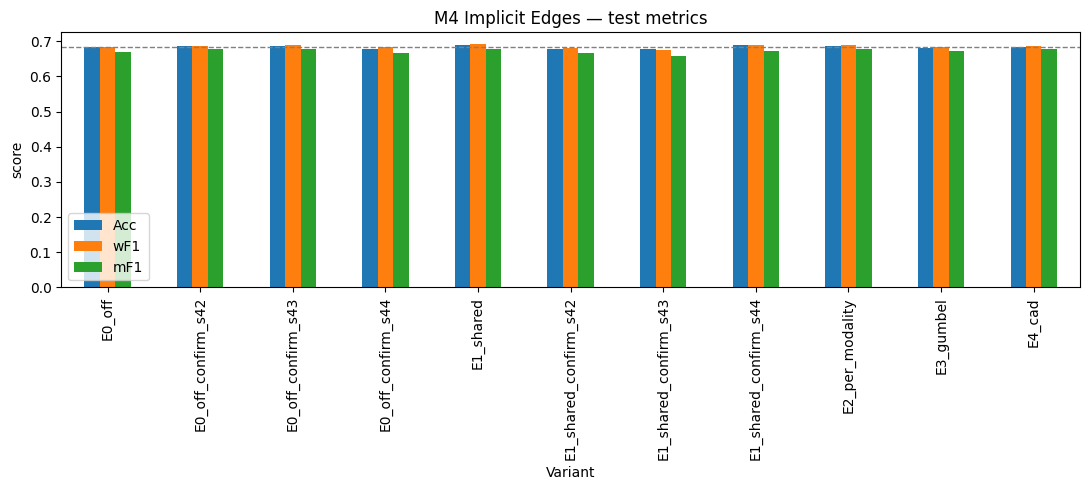

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

res = _load_results()
rows = []
for name, r in sorted(res.items()):
    rows.append({'Variant': name, 'Acc': r['test_acc'], 'wF1': r['test_wf1'],
                 'mF1': r['test_mf1'], 'BestEpoch': r.get('best_val_epoch', -1),
                 **{k: v for k, v in r.items() if k.startswith('pair_')}})
df = pd.DataFrame(rows).set_index('Variant')

REFERENCE = 'E0_off'
if REFERENCE in df.index:
    for c in ('Acc', 'wF1', 'mF1'):
        df[f'D_{c}'] = df[c] - df.loc[REFERENCE, c]

print(f'=== M4 Implicit Edges — results (reference: {REFERENCE}) ===')
print(df.to_string(float_format='{:.4f}'.format))
df.to_csv(ABL_OUT / 'summary_table.csv')

ax = df[['Acc', 'wF1', 'mF1']].plot.bar(figsize=(max(10, len(df)), 5))
if REFERENCE in df.index:
    ax.axhline(df.loc[REFERENCE, 'wF1'], ls='--', c='gray', lw=1)
plt.title('M4 Implicit Edges — test metrics'); plt.ylabel('score'); plt.tight_layout()
plt.savefig(PLOT_DIR / 'metrics_bar.png', dpi=150); plt.show()


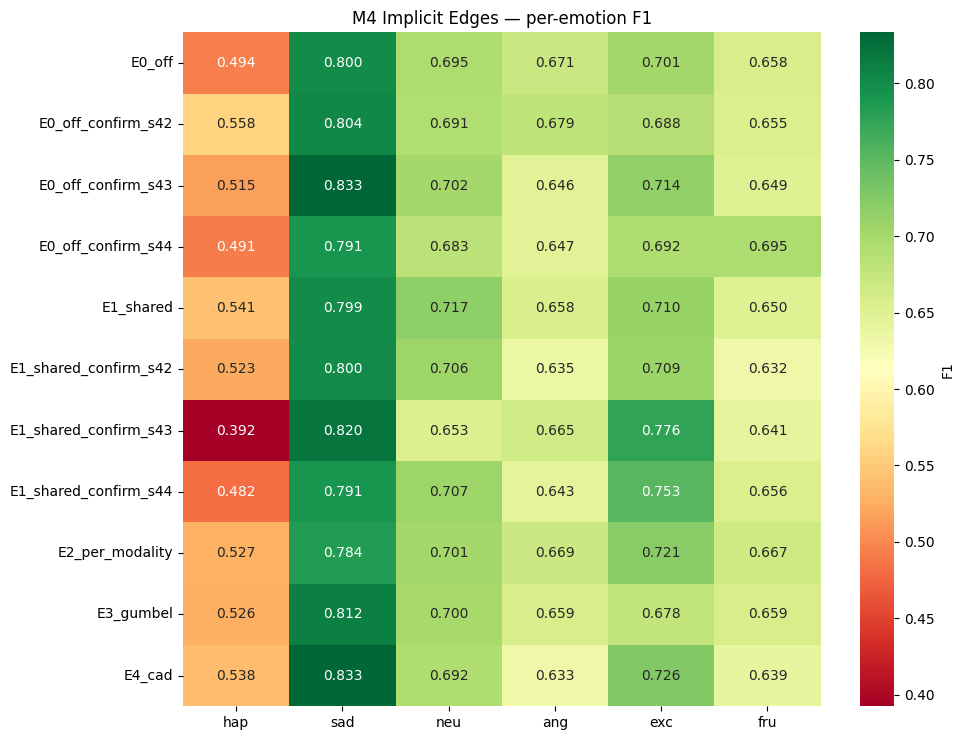

In [17]:
heat = {}
for name, r in res.items():
    yt = np.array(r.get('y_true', [])); yp = np.array(r.get('y_pred', []))
    if len(yt) == 0:
        continue
    heat[name] = f1_score(yt, yp, average=None, labels=list(range(N_CLS)))
if heat:
    hdf = pd.DataFrame(heat, index=EMO).T.sort_index()
    plt.figure(figsize=(10, 0.5 * len(hdf) + 2))
    sns.heatmap(hdf, annot=True, fmt='.3f', cmap='RdYlGn',
                cbar_kws={'label': 'F1'})
    plt.title('M4 Implicit Edges — per-emotion F1'); plt.tight_layout()
    plt.savefig(PLOT_DIR / 'per_emotion_heatmap.png', dpi=150); plt.show()


In [18]:
# McNemar significance of every variant vs the reference
res = _load_results()
ref = 'E0_off'
if ref in res:
    print(f'McNemar p-values vs {ref}:')
    for name in sorted(res):
        if name == ref or not res[name].get('y_pred'):
            continue
        try:
            p = mcnemar_vs(ref, name)
            sig = ' *' if p < 0.05 else ''
            print(f'  {name:35s} p={p:.4f}{sig}')
        except Exception as e:
            print(f'  {name:35s} failed: {e}')


McNemar p-values vs E0_off:
  E0_off_confirm_s42                  p=0.7806
  E0_off_confirm_s43                  p=0.8445
  E0_off_confirm_s44                  p=0.7416
  E1_shared                           p=0.6002
  E1_shared_confirm_s42               p=0.5596
  E1_shared_confirm_s43               p=0.7124
  E1_shared_confirm_s44               p=0.5905
  E2_per_modality                     p=0.6291
  E3_gumbel                           p=0.8336
  E4_cad                              p=1.0000


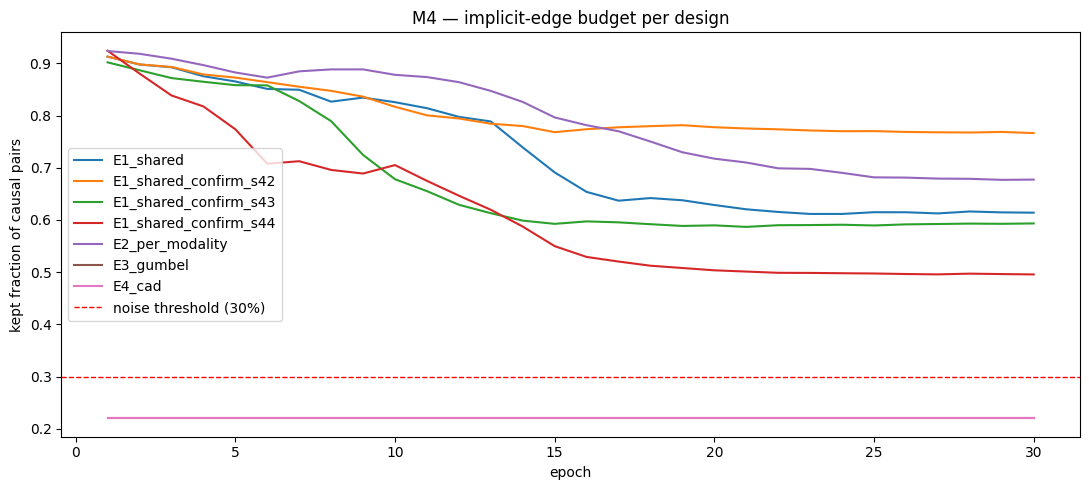

In [19]:
# Edge-count telemetry across epochs (mechanism evidence for the paper)
plt.figure(figsize=(11, 5))
for name in sorted(res):
    hf = CKPT_DIR / f'{name}_history.json'
    if not hf.exists():
        continue
    h = json.load(open(hf))['history']
    if 'imp_kept_frac' not in h[-1]:
        continue
    plt.plot([e['epoch'] for e in h],
             [e.get('imp_kept_frac', 0) for e in h], label=name)
plt.axhline(0.30, ls='--', c='red', lw=1, label='noise threshold (30%)')
plt.xlabel('epoch'); plt.ylabel('kept fraction of causal pairs')
plt.title('M4 — implicit-edge budget per design'); plt.legend(); plt.tight_layout()
plt.savefig(PLOT_DIR / 'edge_budget_curves.png', dpi=150); plt.show()
